In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import MACCSkeys
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

Importación de la colección de compuestos a probar

In [3]:
ruta_sdf = '../data/raw/cmnpd-07-2026.sdf' # Asegúrate de que el nombre del archivo es correcto
proveedor_sdf = Chem.SDMolSupplier(ruta_sdf)

Extracción de SMILES a partir de las moléculas

In [4]:
lista_smiles = []
for mol in proveedor_sdf:
    if mol is not None:
        lista_smiles.append(Chem.MolToSmiles(mol))

df_nuevos = pd.DataFrame({'Smiles': lista_smiles})
print(f"Se extrajeron {len(df_nuevos)} compuestos válidos del SDF.")

Se extrajeron 30700 compuestos válidos del SDF.


In [5]:
# 2. Recuperar los nombres de tus descriptores filtrados 
df_fisico_entrenamiento = pd.read_csv('../data/processed/fisicoquimicos_filtrados.csv')
df_maccs_entrenamiento = pd.read_csv('../data/processed/maccs_filtrados.csv')

In [6]:
# 3.Extraemos los nombres de las columnas, eliminando la variable objetivo
nombres_fisico = df_fisico_entrenamiento.drop(columns=['pChEMBL_Value']).columns.tolist()
nombres_maccs = df_maccs_entrenamiento.drop(columns=['pChEMBL_Value']).columns.tolist()

# 4. Para las MACCS Keys, extraemos solo el número (ej. de 'MACCS_115' sacamos 115) 
# Esto es vital para saber qué posiciones del vector binario pedirle a RDKit
indices_maccs = [int(nombre.split('_')[1]) for nombre in nombres_maccs]

print(f"¡Éxito! Se han recuperado {len(nombres_fisico)} descriptores fisicoquímicos.")
print(f"¡Éxito! Se han recuperado {len(indices_maccs)} claves MACCS.")

¡Éxito! Se han recuperado 34 descriptores fisicoquímicos.
¡Éxito! Se han recuperado 49 claves MACCS.


In [7]:
# 5. Configuramos el calculador fisicoquímico de RDKit solo para los descriptores elegidos
calc_fisico = MoleculeDescriptors.MolecularDescriptorCalculator(nombres_fisico)

# Función para calcular exactamente los descriptores requeridos
def calcular_descriptores_filtrados(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        try:
            # Calculamos los 34 fisicoquímicos
            fisicos = list(calc_fisico.CalcDescriptors(mol))
            
            # Calculamos las MACCS Keys y extraemos solo las 49 que importan
            maccs_full = MACCSkeys.GenMACCSKeys(mol)
            maccs_filtrados = [maccs_full[i] for i in indices_maccs]
            
            return fisicos + maccs_filtrados
        except:
            pass # Si falla el cálculo matemático para alguna molécula compleja
            
    # Devuelve nulos si la molécula es inválida o el cálculo falló
    return [np.nan] * (len(nombres_fisico) + len(nombres_maccs))

In [8]:
# 6. Ejecutamos el cálculo sobre los compuestos extraídos (df_nuevos)
print("Calculando descriptores (esto puede tardar unos minutos)...")
resultados = df_nuevos['Smiles'].apply(calcular_descriptores_filtrados)

Calculando descriptores (esto puede tardar unos minutos)...


In [9]:
# 7. Construimos un DataFrame temporal global y añadimos los SMILES
df_temp = pd.DataFrame(resultados.tolist(), columns=nombres_fisico + nombres_maccs)
df_temp.insert(0, 'Smiles', df_nuevos['Smiles'])

In [10]:
# 8. Limpiamos los compuestos que dieron error para asegurar que todo cuadra perfectamente
df_temp_limpio = df_temp.dropna().reset_index(drop=True)
print(f"Cálculo completado. Quedan {len(df_temp_limpio)} compuestos válidos.")

Cálculo completado. Quedan 30700 compuestos válidos.


In [11]:
# 9. Dividimos el df que hemos creado y limpiado en dos distintos con los descriptores asociados a cada modelo

# DataFrame 1: Solo SMILES y Fisicoquímicos
df_final_fisico = df_temp_limpio[['Smiles'] + nombres_fisico]
df_final_fisico.to_csv('../data/processed/candidatos_cmnpd_fisicoquimicos.csv', index=False)

# DataFrame 2: Solo SMILES y MACCS Keys
df_final_maccs = df_temp_limpio[['Smiles'] + nombres_maccs]
df_final_maccs.to_csv('../data/processed/candidatos_cmnpd_maccs.csv', index=False)

In [12]:
# 10. Extraemos las matrices X (solo los números, quitando la columna SMILES) para poder predecir
X_nuevos_fisico = df_final_fisico.drop(columns=['Smiles']).values
X_nuevos_maccs = df_final_maccs.drop(columns=['Smiles']).values

print("\nDataFrames separados con éxito:")
print(f"Tamaño matriz Fisicoquímica: {X_nuevos_fisico.shape}")
print(f"Tamaño matriz MACCS Keys:    {X_nuevos_maccs.shape}")


DataFrames separados con éxito:
Tamaño matriz Fisicoquímica: (30700, 34)
Tamaño matriz MACCS Keys:    (30700, 49)


Ahora tenemos que predecir los valores de ChEMBL de cada compuesto a partir de los modelos que ya tenemos entrenados.

In [13]:
# 1. Importamos los modelos ya obtenidos en el notebook anterior
rf_fisico = joblib.load('../results/models/mejor_modelo_fisicoquimico.pkl')
rf_maccs = joblib.load('../results/models/mejor_modelo_maccs.pkl')

In [14]:
# 2. Generar predicciones con cada modelo usando las matrices creadas
print("Evaluando compuestos en el modelo Fisicoquímico...")
pred_fisico = rf_fisico.predict(X_nuevos_fisico)

print("Evaluando compuestos en el modelo MACCS Keys...")
pred_maccs = rf_maccs.predict(X_nuevos_maccs)

Evaluando compuestos en el modelo Fisicoquímico...
Evaluando compuestos en el modelo MACCS Keys...


In [15]:
# 3. Crear un DataFrame uniendo los SMILES con los resultados de las predicciones
# (Usamos df_final_fisico['Smiles'] porque mantiene el orden exacto de las matrices)
df_resultados = pd.DataFrame({
    'Smiles': df_final_fisico['Smiles'],
    'pChEMBL_Fisico': pred_fisico,
    'pChEMBL_MACCS': pred_maccs
})

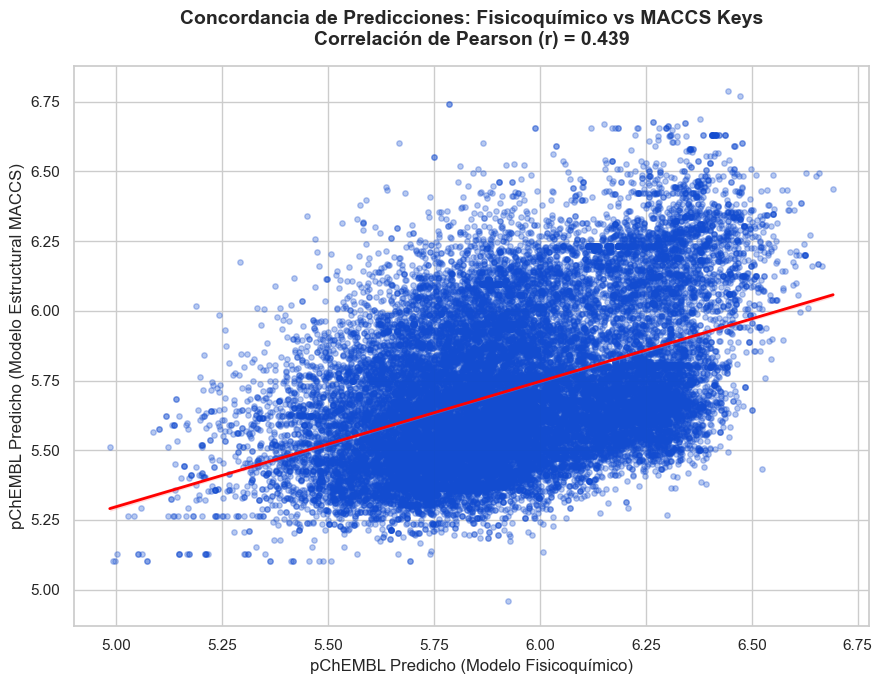

In [16]:
# 1. Calcular la correlación de Pearson y su p-valor
corr, p_value = pearsonr(df_resultados['pChEMBL_Fisico'], df_resultados['pChEMBL_MACCS'])

# 2. Configurar el estilo del gráfico
plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de dispersión con línea de regresión (regplot)
# Usamos un 'alpha' bajo (transparencia) porque tenemos muchos miles de puntos
ax = sns.regplot(x='pChEMBL_Fisico', y='pChEMBL_MACCS', data=df_resultados, 
                 scatter_kws={'alpha': 0.3, 'color': "#134cd0", 's': 15}, 
                 line_kws={'color': 'red', 'linewidth': 2})

# 4. Personalizar títulos y etiquetas para que quede perfecto para el TFM
plt.title(f'Concordancia de Predicciones: Fisicoquímico vs MACCS Keys\nCorrelación de Pearson (r) = {corr:.3f}', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('pChEMBL Predicho (Modelo Fisicoquímico)', fontsize=12)
plt.ylabel('pChEMBL Predicho (Modelo Estructural MACCS)', fontsize=12)

plt.tight_layout()

# 5. Guardar la imagen en alta resolución para pegarla en el documento de tu TFM
plt.savefig('../results/Correlacion_Modelos_CMNPD.png', dpi=300)
plt.show()

In [17]:
# 4. Aplicar la Regla de Consenso Estricta (Umbral pChEMBL >= 6.0 en AMBOS)
umbral = 6.0
candidatos_top = df_resultados[(df_resultados['pChEMBL_Fisico'] >= umbral) & 
                               (df_resultados['pChEMBL_MACCS'] >= umbral)]

candidatos_top['Media_Predicciones'] = (candidatos_top['pChEMBL_Fisico'] + candidatos_top['pChEMBL_MACCS']) / 2

C:\Users\jpela\AppData\Local\Temp\ipykernel_14504\2664758038.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidatos_top['Media_Predicciones'] = (candidatos_top['pChEMBL_Fisico'] + candidatos_top['pChEMBL_MACCS']) / 2


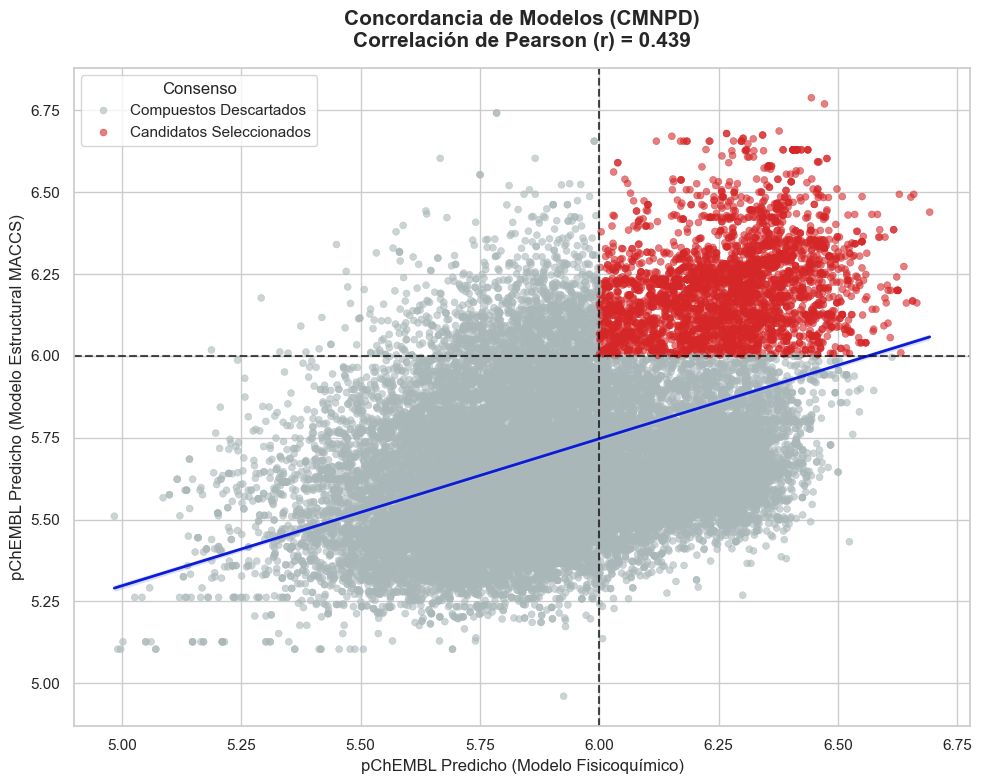

In [27]:
# 1. Calcular la correlación de Pearson
corr, p_value = pearsonr(df_resultados['pChEMBL_Fisico'], df_resultados['pChEMBL_MACCS'])

# 2. CREAR LA CONDICIÓN: Nueva columna que vale 'True' si supera 6.0 en ambos
umbral = 6.0
df_resultados['Supera_Umbral'] = (df_resultados['pChEMBL_Fisico'] >= umbral) & (df_resultados['pChEMBL_MACCS'] >= umbral)

# 3. Configurar el estilo del gráfico
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 4. Definir los colores: Gris azulado para la mayoría, Rojo vivo para el resto
paleta_colores = {False: '#aab7b8', True: '#d62728'}

# 5. Pintar los puntos usando 'hue' para separar por colores según tu umbral
sns.scatterplot(x='pChEMBL_Fisico', y='pChEMBL_MACCS', data=df_resultados, 
                hue='Supera_Umbral', palette=paleta_colores, 
                alpha=0.6, s=25, edgecolor=None)

# 6. Añadir la línea de tendencia general por encima (sin pintar los puntos otra vez)
sns.regplot(x='pChEMBL_Fisico', y='pChEMBL_MACCS', data=df_resultados, 
            scatter=False, line_kws={'color': "#0b1cd8", 'linewidth': 2, 'linestyle': '-'})

# 7. Personalizar títulos, etiquetas y líneas de corte
plt.title(f'Concordancia de Modelos (CMNPD)\nCorrelación de Pearson (r) = {corr:.3f}', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('pChEMBL Predicho (Modelo Fisicoquímico)', fontsize=12)
plt.ylabel('pChEMBL Predicho (Modelo Estructural MACCS)', fontsize=12)

# Líneas punteadas marcando tu umbral estricto de 6.0
plt.axvline(x=umbral, color='black', linestyle='--', alpha=0.7)
plt.axhline(y=umbral, color='black', linestyle='--', alpha=0.7)

# --- REPARACIÓN DEL ERROR AQUÍ ---
# Extraemos los objetos gráficos generados en el lienzo para poder ordenarlos
handles, labels = plt.gca().get_legend_handles_labels()

# Corrección de la leyenda usando los objetos que acabamos de extraer
plt.legend(
    handles=handles[:2], 
    labels=['Compuestos Descartados', 'Candidatos Seleccionados'], 
    loc='upper left',
    title='Consenso'
)

plt.tight_layout()

# 5. Guardar la imagen en alta resolución para pegarla en el documento de tu TFM
plt.savefig('../results/Correlacion_Consenso_CMNPD.png', dpi=300)
plt.show()

In [28]:
# 5. Ordenar los mejores candidatos de mayor a menor potencial según su consenso
candidatos_top = candidatos_top.sort_values(by='Media_Predicciones', ascending=False).reset_index(drop=True)

print(f"\n¡Cribado finalizado! De los compuestos evaluados, se encontraron {len(candidatos_top)} super-inhibidores potenciales.")
candidatos_top.head(10)


¡Cribado finalizado! De los compuestos evaluados, se encontraron 3444 super-inhibidores potenciales.


,Smiles,pChEMBL_Fisico,pChEMBL_MACCS,Media_Predicciones
0,CC[C@H]1C=CCC[C@@]2(CC3CCc4c(C(=O)OCCCCCCCCCCC...,6.471764,6.769606,6.620685
1,CC[C@H]1C=CCC[C@@]2(C[C@@H]3CCc4c(C(=O)OCCCCCC...,6.444253,6.788350,6.616301
2,CNCCc1cc(Br)c(OCCCNC(=O)N(C)CCc2cc(Br)c(OCCCNC...,6.658717,6.493504,6.576110
3,COC1=C(Br)C[C@]2(OC=C1Br)ON=C(C(=O)NCCCOc1c(Br...,6.652632,6.484854,6.568743
4,COC(=O)N(C)CCCOc1c(Br)cc(CCNC(=O)/C(Cc2ccc(OC)...,6.692030,6.438932,6.565481
5,CNCCc1cc(Br)c(OCCCNC(=O)N(C)CCc2cc(Br)c(OCCCNC...,6.628480,6.493504,6.560992
6,COC[C@@H]([C@H](O)[C@H](O)C(=O)NCC[C@H](C)c1nc...,6.476783,6.602736,6.539760
7,COC[C@@H]([C@H](O)[C@H](O)C(=O)NCC[C@H](C)c1nc...,6.476783,6.602736,6.539760
8,COC[C@@H]([C@H](O)[C@H](O)C(=O)N[C@H](C)C[C@H]...,6.436806,6.629346,6.533076
9,COC[C@@H]([C@H](O)[C@H](O)C(=O)N[C@H](C)C[C@H]...,6.436806,6.629346,6.533076


In [ ]:
# 6. Guardar los súper-candidatos para tu TFM
candidatos_top.to_csv('../results/TOP_inhibidores_FabI_CMNPD.csv', index=False)